In [1]:
import re
import string
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

df = pd.read_csv("spam.csv", encoding="latin-1")

df = df[["v1", "v2"]]
df.columns = ["label", "message"]

before = len(df)

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

after = len(df)

df["target"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

print("Duplicates Removed:", before - after)
print("Dataset Shape:", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nClass Distribution (%)")
print(df["label"].value_counts(normalize=True) * 100)

baseline = (df["target"] == 0).mean()

print("\nNaive Baseline Accuracy:", round(baseline * 100, 2), "%")

Duplicates Removed: 403
Dataset Shape: (5169, 3)

Missing Values
label      0
message    0
target     0
dtype: int64

Class Distribution (%)
label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64

Naive Baseline Accuracy: 87.37 %


        char_count   word_count  digit_count  upper_count  punct_count  \
count  5169.000000  5169.000000  5169.000000  5169.000000  5169.000000   
mean     78.977945    15.340685     2.205069     5.337009     4.091120   
std      58.236293    11.068488     6.025241    11.155901     4.444055   
min       2.000000     1.000000     0.000000     0.000000     0.000000   
25%      36.000000     7.000000     0.000000     1.000000     2.000000   
50%      60.000000    12.000000     0.000000     2.000000     3.000000   
75%     117.000000    22.000000     1.000000     4.000000     6.000000   
max     910.000000   171.000000    47.000000   128.000000   133.000000   

       has_currency  has_exclamation      has_url  
count   5169.000000      5169.000000  5169.000000  
mean       0.045463         0.161540     0.017992  
std        0.208338         0.368064     0.132935  
min        0.000000         0.000000     0.000000  
25%        0.000000         0.000000     0.000000  
50%        0.000000  

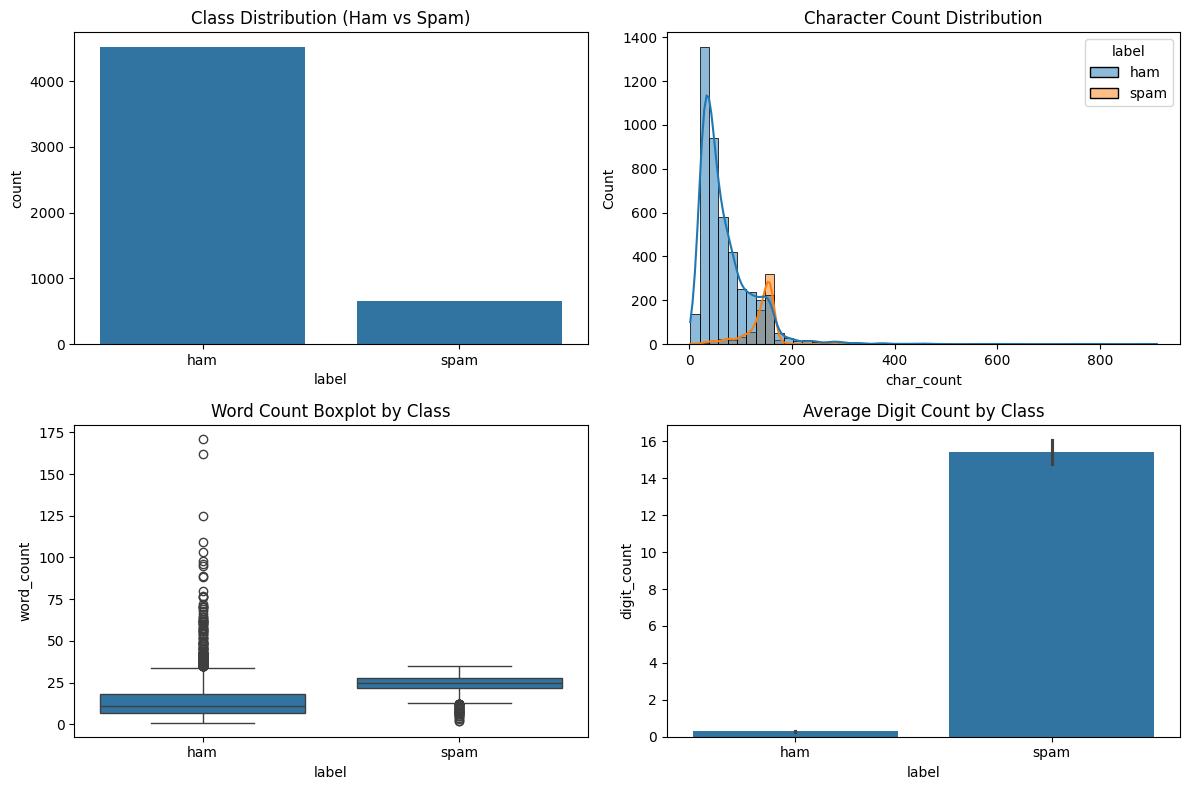

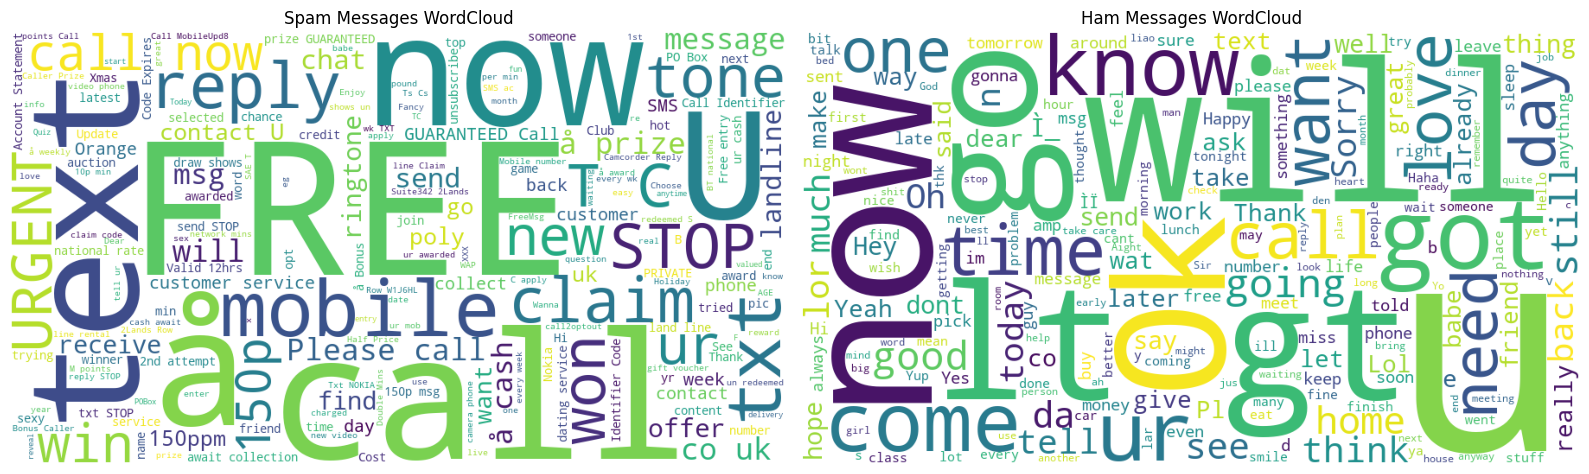

In [2]:
def count_words(text):
    return len(text.split())

def count_digits(text):
    return sum(char.isdigit() for char in text)

def count_upper(text):
    return sum(char.isupper() for char in text)

def count_punctuation(text):
    return sum(char in string.punctuation for char in text)

def has_currency(text):
    return int(bool(re.search(r"[£$]", text)))

def has_exclamation(text):
    return int("!" in text)

def has_url(text):
    return int(bool(re.search(r"http|www", text, re.IGNORECASE)))


df["char_count"] = df["message"].apply(len)
df["word_count"] = df["message"].apply(count_words)
df["digit_count"] = df["message"].apply(count_digits)
df["upper_count"] = df["message"].apply(count_upper)
df["punct_count"] = df["message"].apply(count_punctuation)
df["has_currency"] = df["message"].apply(has_currency)
df["has_exclamation"] = df["message"].apply(has_exclamation)
df["has_url"] = df["message"].apply(has_url)


print(df[[
    "char_count",
    "word_count",
    "digit_count",
    "upper_count",
    "punct_count",
    "has_currency",
    "has_exclamation",
    "has_url"
]].describe())


fig, axes = plt.subplots(2, 2, figsize=(12, 8))


sns.countplot(
    data=df,
    x="label",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Class Distribution (Ham vs Spam)")


sns.histplot(
    data=df,
    x="char_count",
    hue="label",
    kde=True,
    bins=50,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Character Count Distribution")


sns.boxplot(
    data=df,
    x="label",
    y="word_count",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Word Count Boxplot by Class")


sns.barplot(
    data=df,
    x="label",
    y="digit_count",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Average Digit Count by Class")


plt.tight_layout()
plt.show()


spam_text = " ".join(df[df["target"] == 1]["message"])
ham_text = " ".join(df[df["target"] == 0]["message"])


spam_wc = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(spam_text)


ham_wc = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(ham_text)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))


axes[0].imshow(spam_wc)
axes[0].axis("off")
axes[0].set_title("Spam Messages WordCloud")


axes[1].imshow(ham_wc)
axes[1].axis("off")
axes[1].set_title("Ham Messages WordCloud")


plt.tight_layout()
plt.show()

In [3]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english')) - {'free', 'urltoken', 'moneytoken'}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}(/\S*)?|\[\s*http\S+\s*\]|\[\s*[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}/\S*\s*\]', ' urltoken ', text)
    text = re.sub(r'[\$£€]\s*\d+(?:\.\d+)?|\d+\s*[\$£€]', ' moneytoken ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = nltk.word_tokenize(text)
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['cleaned_message'] = df['message'].apply(clean_text)

X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_message'], 
    df['target'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df['target']
)

print("Cleaned Messages:")
print(df[['message', 'cleaned_message']].head())

print("\nTraining Data Size:", X_train.shape)
print("Testing Data Size:", X_test.shape)

print("\nTraining Labels:")
print(y_train.value_counts())

print("\nTesting Labels:")
print(y_test.value_counts())

Cleaned Messages:
                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                     cleaned_message  
0  go jurong point crazi avail bugi n great world...  
1                              ok lar joke wif u oni  
2  free entri wkli comp win fa cup final tkt st m...  
3                u dun say earli hor u c alreadi say  
4               nah think goe usf live around though  

Training Data Size: (4135,)
Testing Data Size: (1034,)

Training Labels:
target
0    3613
1     522
Name: count, dtype: int64

Testing Labels:
target
0    903
1    131
Name: count, dtype: int64


In [4]:
bow_vec = CountVectorizer(max_features=3000, min_df=2, max_df=0.95)

X_train_bow = bow_vec.fit_transform(X_train)
X_test_bow = bow_vec.transform(X_test)


tfidf_vec = TfidfVectorizer(max_features=3000, min_df=2, max_df=0.95)

X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf = tfidf_vec.transform(X_test)


tfidf_ngram_vec = TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2)
)

X_train_ngram = tfidf_ngram_vec.fit_transform(X_train)
X_test_ngram = tfidf_ngram_vec.transform(X_test)


print("BOW Features:")
print("Training Shape:", X_train_bow.shape)
print("Testing Shape:", X_test_bow.shape)

print("\nTF-IDF Features:")
print("Training Shape:", X_train_tfidf.shape)
print("Testing Shape:", X_test_tfidf.shape)

print("\nTF-IDF N-gram Features:")
print("Training Shape:", X_train_ngram.shape)
print("Testing Shape:", X_test_ngram.shape)


print("\nSample BOW Words:")
print(bow_vec.get_feature_names_out()[:20])

print("\nSample TF-IDF Words:")
print(tfidf_vec.get_feature_names_out()[:20])

print("\nSample N-gram Words:")
print(tfidf_ngram_vec.get_feature_names_out()[:20])

BOW Features:
Training Shape: (4135, 2486)
Testing Shape: (1034, 2486)

TF-IDF Features:
Training Shape: (4135, 2486)
Testing Shape: (1034, 2486)

TF-IDF N-gram Features:
Training Shape: (4135, 3000)
Testing Shape: (1034, 3000)

Sample BOW Words:
['aah' 'abi' 'abil' 'abiola' 'abl' 'abt' 'aburo' 'abus' 'ac' 'acc'
 'accept' 'access' 'accid' 'accident' 'accomod' 'account' 'ach' 'acl'
 'across' 'act']

Sample TF-IDF Words:
['aah' 'abi' 'abil' 'abiola' 'abl' 'abt' 'aburo' 'abus' 'ac' 'acc'
 'accept' 'access' 'accid' 'accident' 'accomod' 'account' 'ach' 'acl'
 'across' 'act']

Sample N-gram Words:
['aah' 'abi' 'abiola' 'abl' 'abl deliv' 'abl get' 'abl pay' 'abt'
 'abt alreadi' 'abt tht' 'abt ur' 'aburo' 'aburo enjoy' 'abus' 'ac' 'acc'
 'accept' 'access' 'access number' 'accid']


Optimal Alpha for MultinomialNB: 0.1 (Cross-Validation Macro F1: 0.9525)

MODEL COMPARISON TABLE:
                Model Configuration  Accuracy  Precision (Spam)  Recall (Spam)  F1 (Spam)  CV F1 (Mean)
            1. BoW + Multinomial NB    0.9816            0.9179         0.9389     0.9283        0.9542
         2. TF-IDF + Multinomial NB    0.9778            0.9500         0.8702     0.9084        0.9527
             3. BoW + Complement NB    0.9584            0.7750         0.9466     0.8522        0.9131
    4. TF-IDF + Logistic Regression    0.9613            0.9892         0.7023     0.8214        0.8820
5. TF-IDF (1,2 n-grams) + Tuned MNB    0.9739            0.9407         0.8473     0.8916        0.9535


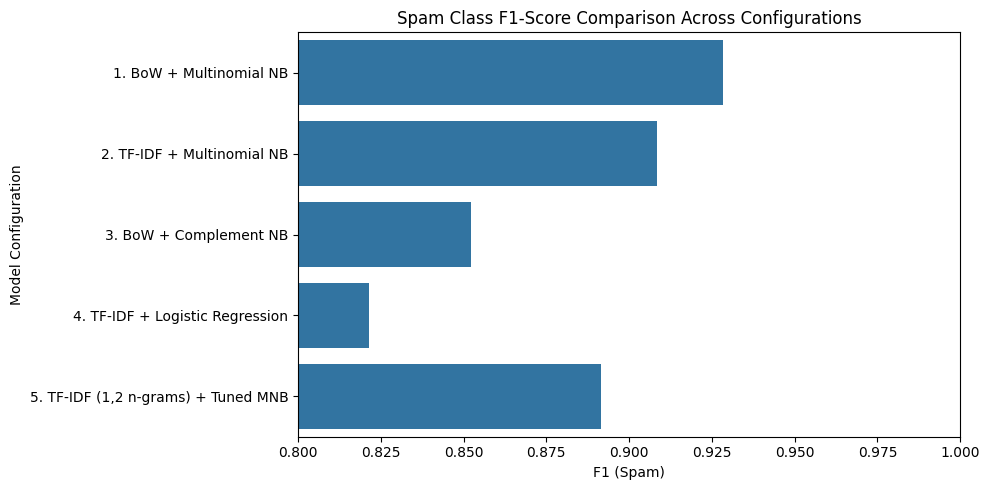

In [5]:
alphas = [0.1, 0.5, 1.0, 2.0, 5.0]
best_alpha = 1.0
best_score = 0.0

for alpha in alphas:
    model = MultinomialNB(alpha=alpha)
    scores = cross_val_score(model, X_train_ngram, y_train, cv=5, scoring="f1_macro")
    mean_score = scores.mean()
    if mean_score > best_score:
        best_score = mean_score
        best_alpha = alpha

print(f"Optimal Alpha for MultinomialNB: {best_alpha} (Cross-Validation Macro F1: {best_score:.4f})\n")

model_configs = {
    "1. BoW + Multinomial NB": (MultinomialNB(alpha=best_alpha), X_train_bow, X_test_bow),
    "2. TF-IDF + Multinomial NB": (MultinomialNB(alpha=best_alpha), X_train_tfidf, X_test_tfidf),
    "3. BoW + Complement NB": (ComplementNB(alpha=best_alpha), X_train_bow, X_test_bow),
    "4. TF-IDF + Logistic Regression": (LogisticRegression(max_iter=1000, C=1.0, random_state=42), X_train_tfidf, X_test_tfidf),
    "5. TF-IDF (1,2 n-grams) + Tuned MNB": (MultinomialNB(alpha=best_alpha), X_train_ngram, X_test_ngram)
}

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, (model, X_tr, X_te) in model_configs.items():
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    cv_scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring='f1_macro')
    
    results.append({
        "Model Configuration": name,
        "Accuracy": round(accuracy_score(y_test, preds), 4),
        "Precision (Spam)": round(precision_score(y_test, preds, pos_label=1), 4),
        "Recall (Spam)": round(recall_score(y_test, preds, pos_label=1), 4),
        "F1 (Spam)": round(f1_score(y_test, preds, pos_label=1), 4),
        "CV F1 (Mean)": round(cv_scores.mean(), 4)
    })

summary_df = pd.DataFrame(results)
print("MODEL COMPARISON TABLE:")
print(summary_df.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(
    data=summary_df,
    x="F1 (Spam)",
    y="Model Configuration"
)
plt.title("Spam Class F1-Score Comparison Across Configurations")
plt.xlim(0.8, 1.0)
plt.tight_layout()
plt.show()

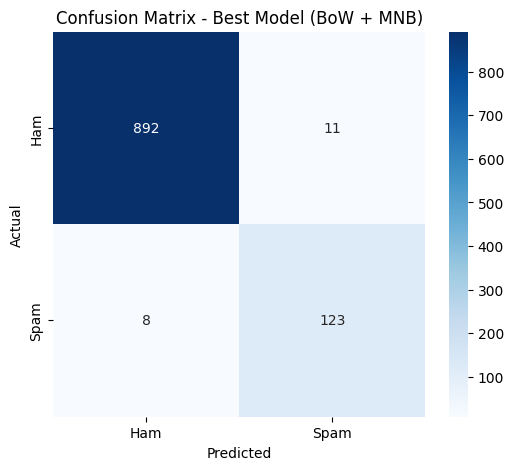


DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       903
        Spam       0.92      0.94      0.93       131

    accuracy                           0.98      1034
   macro avg       0.95      0.96      0.96      1034
weighted avg       0.98      0.98      0.98      1034



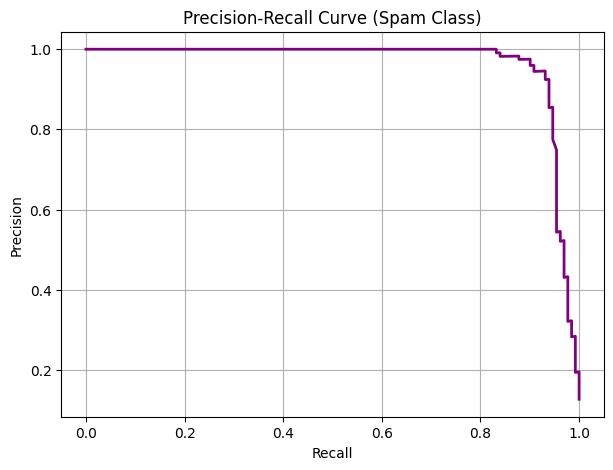

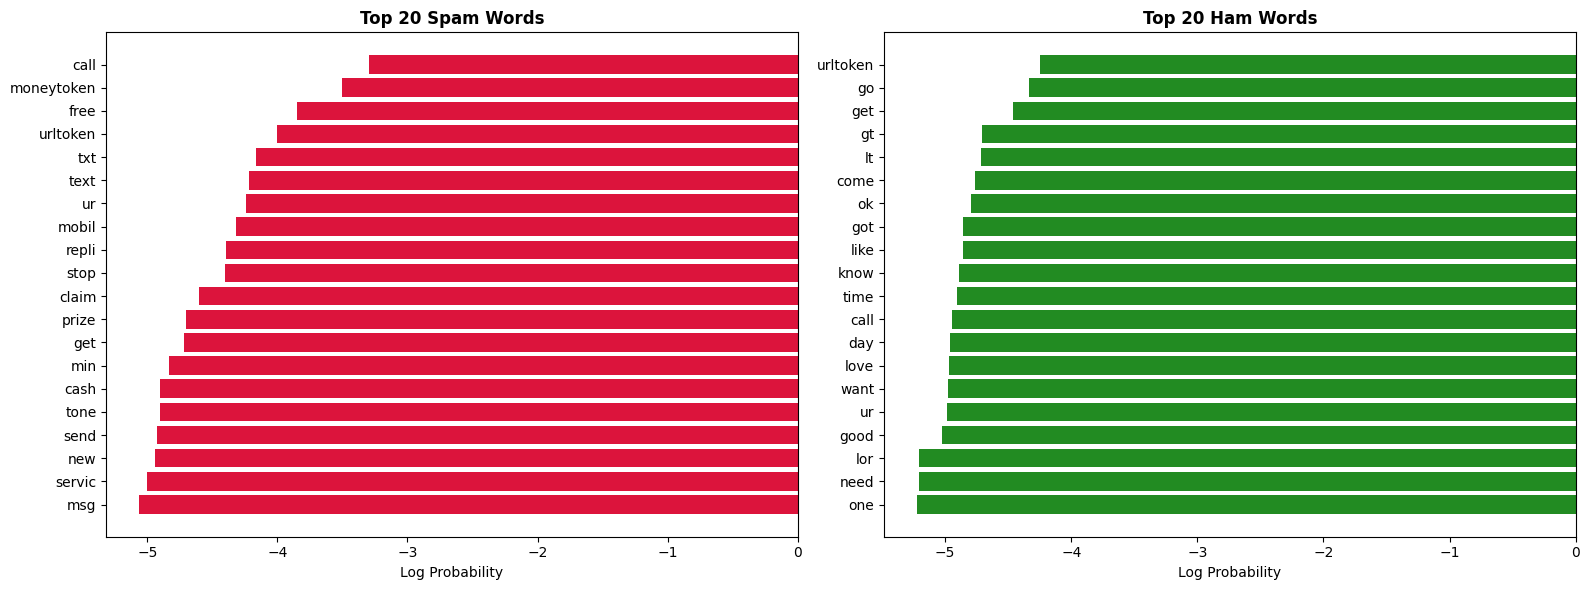

In [6]:
best_vec = bow_vec
best_model = MultinomialNB(alpha=best_alpha)
best_model.fit(X_train_bow, y_train)
final_preds = best_model.predict(X_test_bow)

cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Best Model (BoW + MNB)')
plt.show()

print("\nDETAILED CLASSIFICATION REPORT:")
print(classification_report(y_test, final_preds, target_names=['Ham', 'Spam']))

y_probs = best_model.predict_proba(X_test_bow)[:, 1]
precisions, recalls, _ = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, color='purple', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Spam Class)')
plt.grid(True)
plt.show()

feature_names = np.array(best_vec.get_feature_names_out())
spam_log_probs = best_model.feature_log_prob_[1]
ham_log_probs = best_model.feature_log_prob_[0]

top_spam_indices = np.argsort(spam_log_probs)[::-1][:20]
top_ham_indices = np.argsort(ham_log_probs)[::-1][:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(feature_names[top_spam_indices][::-1], spam_log_probs[top_spam_indices][::-1], color='crimson')
axes[0].set_title("Top 20 Spam Words", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Log Probability")

axes[1].barh(feature_names[top_ham_indices][::-1], ham_log_probs[top_ham_indices][::-1], color='forestgreen')
axes[1].set_title("Top 20 Ham Words", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Log Probability")
plt.tight_layout()
plt.show()

test_eval_df = pd.DataFrame({
    'raw_message': df.loc[y_test.index, 'message'].values,
    'cleaned_message': X_test.values,
    'actual': y_test.values,
    'predicted': final_preds
})


In [7]:
false_positives = test_eval_df[(test_eval_df['actual'] == 0) & (test_eval_df['predicted'] == 1)]
false_negatives = test_eval_df[(test_eval_df['actual'] == 1) & (test_eval_df['predicted'] == 0)]

print("\nFALSE POSITIVES (Ham misclassified as Spam):")
for idx, row in false_positives.head(5).iterrows():
    print(f"- {row['raw_message']}")

print("\nFALSE NEGATIVES (Spam misclassified as Ham):")
for idx, row in false_negatives.head(5).iterrows():
    print(f"- {row['raw_message']}")


FALSE POSITIVES (Ham misclassified as Spam):
- K:)eng rocking in ashes:)
- How are you. Its been ages. How's abj
- K k:) sms chat with me.
- You call him and tell now infront of them. Call him now.
- Send me the new number

FALSE NEGATIVES (Spam misclassified as Ham):
- Hi babe its Jordan, how r u? Im home from abroad and lonely, text me back if u wanna chat xxSP visionsms.com Text stop to stopCost 150p 08712400603
- ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE MINS. INDIA CUST SERVs SED YES. L8ER GOT MEGA BILL. 3 DONT GIV A SHIT. BAILIFF DUE IN DAYS. I O å£250 3 WANT å£800
- SMS. ac sun0819 posts HELLO:\You seem cool
- Babe: U want me dont u baby! Im nasty and have a thing 4 filthyguys. Fancy a rude time with a sexy bitch. How about we go slo n hard! Txt XXX SLO(4msgs)
- In The Simpsons Movie released in July 2007 name the band that died at the start of the film? A-Green Day, B-Blue Day, C-Red Day. (Send A, B or C)


In [8]:
with open("model.pkl", "wb") as f_model:
    pickle.dump(best_model, f_model)

with open("vectorizer.pkl", "wb") as f_vec:
    pickle.dump(best_vec, f_vec)

print("Successfully saved 'model.pkl' and 'vectorizer.pkl' to disk.")

loaded_model = pickle.load(open("model.pkl", "rb"))
loaded_vec = pickle.load(open("vectorizer.pkl", "rb"))

unseen_messages = [
    "Hey, are we still meeting at the library at 5 PM for the project?",
    "URGENT! You have won a $1,000 Walmart gift card. Click http://bit.ly/claim-prize to claim NOW!",
    "Can you please send me the lecture notes from yesterday's class?",
    "CONGRATULATIONS! Your mobile number has been selected for a £500 cash reward. Call 0800123456 to collect.",
    "Don't forget to buy milk and eggs on your way home."
]

unseen_results = []
for msg in unseen_messages:
    cleaned = clean_text(msg)
    vec_msg = loaded_vec.transform([cleaned])
    pred = loaded_model.predict(vec_msg)[0]
    probs = loaded_model.predict_proba(vec_msg)[0]
    label = "SPAM" if pred == 1 else "HAM"
    unseen_results.append({
        "Message": msg,
        "Predicted Label": label,
        "Ham Probability": round(probs[0], 4),
        "Spam Probability": round(probs[1], 4)
    })

unseen_df = pd.DataFrame(unseen_results)
print("\nNew results:")
print(unseen_df.to_string(index=False))

Successfully saved 'model.pkl' and 'vectorizer.pkl' to disk.

New results:
                                                                                                  Message Predicted Label  Ham Probability  Spam Probability
                                        Hey, are we still meeting at the library at 5 PM for the project?             HAM              1.0               0.0
           URGENT! You have won a $1,000 Walmart gift card. Click http://bit.ly/claim-prize to claim NOW!            SPAM              0.0               1.0
                                         Can you please send me the lecture notes from yesterday's class?             HAM              1.0               0.0
CONGRATULATIONS! Your mobile number has been selected for a £500 cash reward. Call 0800123456 to collect.            SPAM              0.0               1.0
                                                      Don't forget to buy milk and eggs on your way home.             HAM              1.0  

In [9]:
import pickle
import re
import nltk
import gradio as gr
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english')) - {'free', 'urltoken', 'moneytoken'}

loaded_model = pickle.load(open("model.pkl", "rb"))
loaded_vec = pickle.load(open("vectorizer.pkl", "rb"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}(/\S*)?|\[\s*http\S+\s*\]|\[\s*[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}/\S*\s*\]', ' urltoken ', text)
    text = re.sub(r'[\$£€]\s*\d+(?:\.\d+)?|\d+\s*[\$£€]', ' moneytoken ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = nltk.word_tokenize(text)
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

def predict_spam(message):
    cleaned = clean_text(message)
    vec_msg = loaded_vec.transform([cleaned])
    probs = loaded_model.predict_proba(vec_msg)[0]
    
    return {
        "Ham": float(probs[0]),
        "Spam": float(probs[1])
    }

interface = gr.Interface(
    fn=predict_spam,
    inputs=gr.Textbox(lines=4, placeholder="Type or paste a message here to check..."),
    outputs=gr.Label(num_top_classes=2, label="Prediction Confidence"),
    title="SMS & Email Spam Detection System",
    description="Enter any message below to classify it as **HAM** (Legitimate) or **SPAM** using the trained Multinomial Naive Bayes model.",
    examples=[
        ["Hey, are we still meeting at the library at 5 PM for the project?"],
        ["URGENT! You have won a $1,000 Walmart gift card. Click http://bit.ly/claim-prize to claim NOW!"],
        ["CONGRATULATIONS! Your mobile number has been selected for a £500 cash reward. Call 0800123456 to collect."],
        ["Your package could not be delivered due to an incomplete address. Please update your details and pay the $1.95 redelivery fee here: [suspicious-link.com/usps]"]
    ]
)

interface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://5972aad1e38edeec5f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Training Accuracy: 0.9891 | Training Loss: 0.0399
Testing Accuracy:  0.9816 | Testing Loss:  0.0908


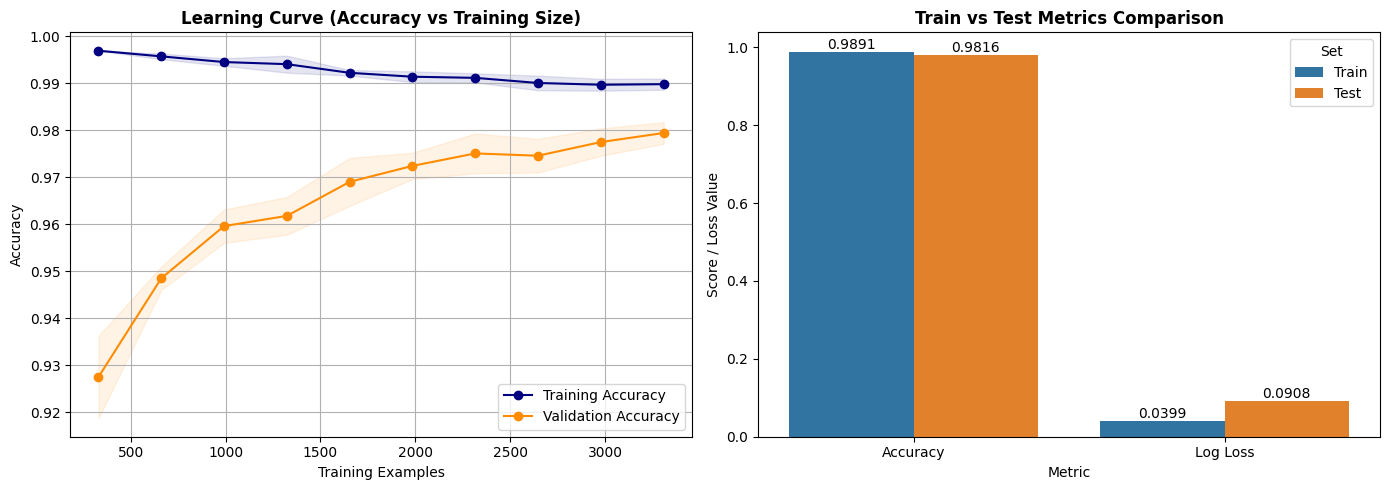

In [10]:
from sklearn.model_selection import learning_curve
from sklearn.metrics import log_loss

train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train_bow, y_train,
    cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

train_probs = best_model.predict_proba(X_train_bow)
test_probs = best_model.predict_proba(X_test_bow)

train_loss = log_loss(y_train, train_probs)
test_loss = log_loss(y_test, test_probs)

train_acc = accuracy_score(y_train, best_model.predict(X_train_bow))
test_acc = accuracy_score(y_test, final_preds)

print(f"Training Accuracy: {train_acc:.4f} | Training Loss: {train_loss:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f} | Testing Loss:  {test_loss:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_sizes, train_mean, 'o-', color='navy', label='Training Accuracy')
axes[0].plot(train_sizes, test_mean, 'o-', color='darkorange', label='Validation Accuracy')
axes[0].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='navy')
axes[0].fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='darkorange')
axes[0].set_title('Learning Curve (Accuracy vs Training Size)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Training Examples')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='lower right')
axes[0].grid(True)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Accuracy', 'Log Loss', 'Log Loss'],
    'Set': ['Train', 'Test', 'Train', 'Test'],
    'Value': [train_acc, test_acc, train_loss, test_loss]
})

sns.barplot(data=metrics_df, x='Metric', y='Value', hue='Set', ax=axes[1], palette=['#1f77b4', '#ff7f0e'])
axes[1].set_title('Train vs Test Metrics Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Score / Loss Value')
for p in axes[1].patches:
    if p.get_height() > 0:
        axes[1].annotate(f'{p.get_height():.4f}', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()